[colab에서 실행하기](https://colab.research.google.com/github/science-odysseia/AILearning/blob/main/OpenCV기초.ipynb)

코랩에서 실행할 경우

아래 코드를 한 번 실행만 시켜 주시고 다음으로 넘어가 주세요.

In [1]:
import os, cv2, numpy as np, matplotlib.pyplot as plt
if "AILearning" not in os.getcwd():
    !git clone https://github.com/science-odysseia/AILearning.git
    os.chdir("/content/AILearning")
try:
    # 코랩 환경 시도
    from google.colab.patches import cv2_imshow
except ImportError:
    def cv2_imshow(img):
        import cv2
        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

%matplotlib inline

# OpenCV 이미지 좌표체계
| numpy 배열 | opencv 이미지 |
| :---: | :---: |
| <img src="imgs/opencv/imgs/numpy1.png" width="300"> | <img src="imgs/opencv/imgs/OpenCV1.png" width="300"> |

특징 : 
- 원점위치 : 왼쪽 위
- x좌표 : 열
- y좌표 : 행

# OpenCV 색상 시스템 : BGR

OpenCV의 기본 색상 시스템은 BGR, 역순으로 처리한다.

가령 입력된 색이 [255, 0, 0] 이라면

B, G, R 순서로 읽어 빨간색이 아니라 파란색으로 처리한다.

아래 코드를 통해 결과를 보자. 코랩에서 실행중이라면 색의 값을 변화시켜 결과를 보는 것도 좋은 방법이다.

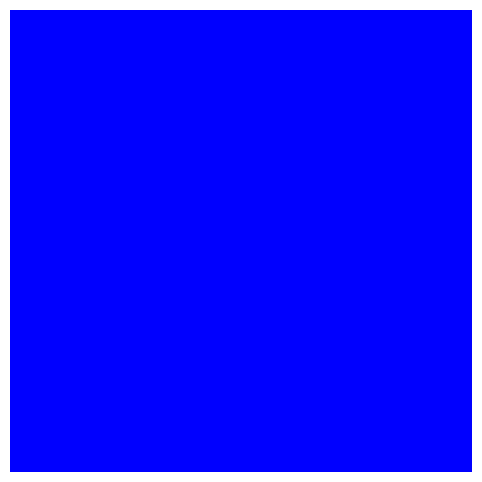

In [21]:
# 300x300x3(3채널 : B, G, R) 사이즈의 [255, 0, 0] 색상 이미지 생성
img = np.full((300, 300, 3), [255, 0, 0], dtype=np.uint8)

cv2_imshow(img)

# OpenCV 기본명령어 : 이미지

### 1. `cv2.imread('경로')`

In [9]:
img = cv2.imread(r'./imgs/opencv/imgs/astronaut.jpg')

`img` 변수에 `astronaut.jpg` 이미지의 넘파이 배열값을 저장하는 코드

### 2. `cv2.imshow('창 이름', 이미지 변수)`



In [ ]:
if False :  # 이 명령어 셀을 실행하지 못하게 만들 목적으로 넣은 것이니, 무시해도 됨.

    cv2.imshow('window', img)

저장한 이미지 변수를 `'창 이름'` 창에 실제로 띄우게 하는 코드

다만 이 경우는 아주 잠깐 뜨다가 사라진다.

아래 코드로 무한 루프를 적용시켜 종료 키가 작동되기 전까지 뜨도록 만들어줘야 유지된다.

In [ ]:
if False: # 이 명령어 셀을 실행하지 못하게 만들 목적으로 넣은 것이니, 무시해도 됨.

    cv2.waitKey(0)
    cv2.destroyAllWindows()

`cv2.waitKey(0)` 안 인자 `0`은

아무 키를 눌렀을 때 창을 종료시키겠다는 의미이고

`cv2.destroyAllWindows()`는

모든 열려있던 창을 종료시키겠다는 의미이다.

참고로 만약 이 코드를 `google Colab`에서 실행시키고 있다면

`cv2.imshow('창 이름', 이미지 변수)` 코드 실행 시 에러가 나는데

이는 `cv2.imshow`가 로컬 시스템에서 동작하는 방식인데, 

Colab의 경우 서버를 이용하는 방식을 사용하기 때문이다.

Colab에서 이를 쓰려면

```python
from google.colab.patches import cv2_imshow
```

의 `cv2_imshow(이미지 변수)`를 사용하면 에러 없이 이미지를 띄울 수 있다.

# OpenCV 기본명령어 : 영상

영상은 이미지의 연속이다.

즉 여러 장의 이미지를 몇 초의 아주 짧은 간격으로 띄울 것인가로 이해하면 된다.

OpenCV 영상 기본 코드 구조는 아래와 같다. (함수 안 코드)

In [ ]:
def video(): # colab에서 이대로 실행하면 제대로 작동하지 않으므로 함수화 함. 내용만 보면 됨.
    import cv2
    cap = cv2.VideoCapture(r'./imgs/opencv/videos/turtle.mp4')

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        cv2.imshow('video', frame)
        
        if cv2.waitKey(10) == ord('q'):      # 대기시간(ms)
            break
        
        # waitkey = 1000/FPS : 1배속 설정

    cap.release()               # 비디오 장치 사용후 자원을 해제
    cv2.destroyAllWindows()     # 모든 opencv 창 닫기

### 1. `cv2.VideoCapture('경로')`

In [3]:
cap = cv2.VideoCapture(r'./imgs/opencv/videos/turtle.mp4')

영상을 받아올 통로 변수 `cap`를 생성하는 명령어이다.

추가로 동영상 데이터 뿐만 아니라 웹캠, 노트북의 카메라 영상 데이터도 가져올 수 있는데

`'경로'` 대신 숫자(0, 1, 2, ...)을 넣으면 된다.

연결된 카메라 순서대로 번호가 붙으며 보통 노트북의 내장 캠이 0번을 받지만 시스템에 따라 다를 수 있다.

### 2. `ret, frame = cap.read()`

In [4]:
ret, frame = cap.read()

연결된 통로로부터 이미지를 1장씩 받아오는 코드.

`ret`은 이미지를 제대로 받은 경우 True, 아닌경우 False값이 되며

`frame`이 받은 이미지의 numpy 배열값이 된다.

### 3. `cv2.waitKey(10) == ord('q')`

In [7]:
if False: # 이 명령어 셀을 실행하지 못하게 만들 목적으로 넣은 것이니, 무시해도 됨.
    while True : 
        if cv2.waitKey(10) == ord('q'):      # 대기시간(ms)
            break

`cv2.waitKey(0)` 는 아무 키나 누를 시 종료하겠다는 코드였다.

`cv2.waitKey(10)` 은 10ms, 즉 0.01초마다 입력키를 확인하겠다는 것이고

`ord(q)`는 `q`키의 번호이다.

즉 10ms(0.01초) 마다 눌러진 키가 `q`인가를 확인하는 코드이자,

while문을 10ms마다 순환하겠다는 코드이므로

영상을 0.01초마다 띄우겠다는 코드이다.

뒤 코드를 보면 알겠지만 `cv2.waitKey(10) == ord('q')` 이면 `break`로 탈출하는데

이는 `q`를 누른 것이 확인되면 영상 송출을 멈추겠다는 코드이다.



### 4. `cap.release()`

`cap`연결을 해제하겠다는 코드이다.

# OpenCV 이미지 조작 기본 명령어

### 원본 이미지

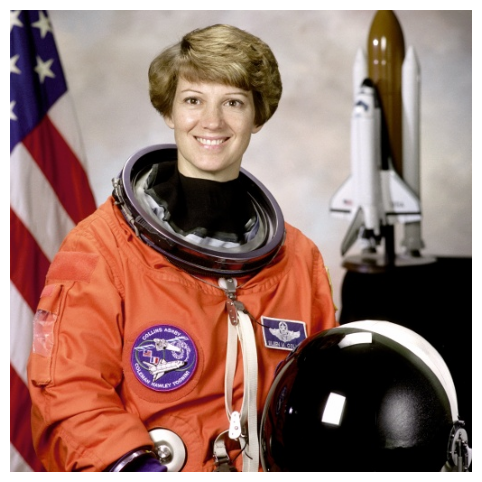

In [10]:
cv2_imshow(img)

### 1. 색 순서 전환

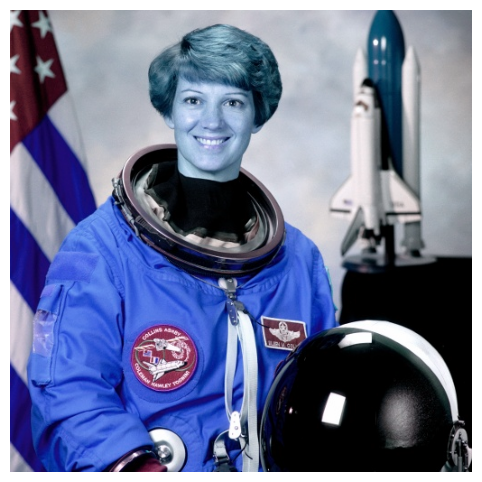

In [25]:
# 색 변환 코드 1줄
img_rev = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 창에 띄우는 코드
cv2_imshow(img_rev) # 로컬은 cv2.imshow('img', img)
